## 문서 로딩

In [3]:
from google import genai
from google.genai import types
import pathlib
import httpx

client = genai.Client()

# Retrieve and encode the PDF byte
file_path = pathlib.Path("data/RAG_25-42.pdf")

# Upload the PDF using the File API
sample_file = client.files.upload(
    file=file_path,
)

prompt = """pdf파일에서 텍스트 내용을 추출해줘. pdf에는 다양한 텍스트와 이미지, 차트가 포함되어 있어.
            텍스트를 추출해주고, 이미지나 차트가 있다면 설명하는 텍스트를 한글로 변환해줘.
        """

response = client.models.generate_content(
    model="gemini-2.5-flash", contents=[sample_file, prompt]
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [4]:
print(response.text)

다음은 PDF 파일에서 추출한 텍스트 내용과 이미지/차트 설명입니다.

---

**CHAPTER 01 RAG 이해하기**

**학습 목표**
RAG(Retrieval-Augmented Generation)는 문서 로드, 검색, 답변 생성의 투명한 과정을 통해 할루시네이션 현상을 줄이고, 최신 정보와 신뢰할 수 있는 외부 데이터를 활용해 응답 정확도를 대폭 향상시킴으로써 GPT 모델의 한계를 극복하기 위한 기술입니다. RAG는 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하여 실용적이며, 사용자가 원하는 대로 데이터베이스와 모델을 커스터마이즈할 수 있어 특정 도메인에 특화된 챗봇을 제작할 수 있는 강력한 도구입니다. 그러한 RAG를 사용해야 하는 이유에 관해 알아보겠습니다.

**01 RAG를 사용해야 하는 이유**

ChatGPT는 2022년 11월 등장하자마자 순식간에 많은 사용자를 확보했습니다. 2023년 11월에는 GPTs 스토어가 출시되어 GPT의 기능을 플러그인으로 제작하고 배포할 수 있게 되었고, 여러 고급 기능이 보완되면서 사용자들은 단순히 질문하고 답변받는 것에서 더 나아가 전문적인 영역까지 ChatGPT를 적극적으로 활용하기 시작했습니다. 이러한 과정에서 점차 다음과 같은 문제점들이 드러나기 시작했습니다.

1.  ChatGPT는 최신 정보가 학습되어 있지 않습니다.
2.  개인이나 회사의 내부 데이터가 학습되어 있지 않아, 특정 도메인(개인 정보, 회사 내부 정보)에 대한 질문에는 기대하는 답변을 얻을 수 없습니다.
3.  ChatGPT에 개인이나 회사 정보를 담은 문서를 업로드하면 보안상 문제가 될 수 있습니다.
4.  문서의 양이 많아질수록 할루시네이션 현상이 발생하기 쉽습니다.

**ChatGPT의 한계를 보완하기 위해 주목받은 RAG**

RAG는 ChatGPT의 한계를 보완하기 위해 주목받기 시작한 기술입니다. RAG란 Retrieval-Augmented Generation의 줄임말로, 검색(Retrieval), 증강(Augme

## Stuff

![alt text](image.png)

In [5]:
from langchain.schema import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 텍스트를 문장 단위로 나누기 위한 설정
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,  # 각 chunk의 최대 크기
    chunk_overlap=100,  # chunk 간 겹치는 부분
    separators=[
        "\n\n",
        "\n",
        ".",
        "!",
        "?",
        ";",
        ",",
        " ",
        "",
    ],  # 문장 단위로 나누기 위한 구분자
)

# response.text를 chunk로 나누기
text_chunks = text_splitter.split_text(response.text)

# Document 객체 리스트로 변환
docs = [Document(page_content=chunk) for chunk in text_chunks]

print(f"총 {len(docs)}개의 문서로 분할되었습니다.")
for i, doc in enumerate(docs):  # 처음 3개만 미리보기
    print(f"\n--- Document {i+1} ---")
    print(doc.page_content)

총 48개의 문서로 분할되었습니다.

--- Document 1 ---
다음은 PDF 파일에서 추출한 텍스트 내용과 이미지/차트 설명입니다.

---

**CHAPTER 01 RAG 이해하기**

**학습 목표**
RAG(Retrieval-Augmented Generation)는 문서 로드, 검색, 답변 생성의 투명한 과정을 통해 할루시네이션 현상을 줄이고, 최신 정보와 신뢰할 수 있는 외부 데이터를 활용해 응답 정확도를 대폭 향상시킴으로써 GPT 모델의 한계를 극복하기 위한 기술입니다. RAG는 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하여 실용적이며, 사용자가 원하는 대로 데이터베이스와 모델을 커스터마이즈할 수 있어 특정 도메인에 특화된 챗봇을 제작할 수 있는 강력한 도구입니다. 그러한 RAG를 사용해야 하는 이유에 관해 알아보겠습니다.

**01 RAG를 사용해야 하는 이유**

--- Document 2 ---
**01 RAG를 사용해야 하는 이유**

ChatGPT는 2022년 11월 등장하자마자 순식간에 많은 사용자를 확보했습니다. 2023년 11월에는 GPTs 스토어가 출시되어 GPT의 기능을 플러그인으로 제작하고 배포할 수 있게 되었고, 여러 고급 기능이 보완되면서 사용자들은 단순히 질문하고 답변받는 것에서 더 나아가 전문적인 영역까지 ChatGPT를 적극적으로 활용하기 시작했습니다. 이러한 과정에서 점차 다음과 같은 문제점들이 드러나기 시작했습니다.

1.  ChatGPT는 최신 정보가 학습되어 있지 않습니다.
2.  개인이나 회사의 내부 데이터가 학습되어 있지 않아, 특정 도메인(개인 정보, 회사 내부 정보)에 대한 질문에는 기대하는 답변을 얻을 수 없습니다.
3.  ChatGPT에 개인이나 회사 정보를 담은 문서를 업로드하면 보안상 문제가 될 수 있습니다.
4.  문서의 양이 많아질수록 할루시네이션 현상이 발생하기 쉽습니다.

--- Document 3 ---
**ChatGPT의 한계를 보완하기 위해 주목받은 RAG**

RAG는 C

In [6]:
from langchain.prompts import ChatPromptTemplate


prompt = ChatPromptTemplate.from_template(
    """다음 요청사항에 맞게 문장을 요약해주세요.
        요청 (REQUEST):
        1. 주요 내용을 요약하여 한글로 불릿 포인트로 정리해 주세요.
        2. 각 요약 문장은 내용에 어울리는 이모지로 시작해야 합니다.
        3. 다양한 이모지를 사용하여 요약을 더 흥미롭게 만들어 주세요.\n\nCONTEXT: {context}\n\nSUMMARY:
    """
)

prompt

ChatPromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='다음 요청사항에 맞게 문장을 요약해주세요.\n        요청 (REQUEST):\n        1. 주요 내용을 요약하여 한글로 불릿 포인트로 정리해 주세요.\n        2. 각 요약 문장은 내용에 어울리는 이모지로 시작해야 합니다.\n        3. 다양한 이모지를 사용하여 요약을 더 흥미롭게 만들어 주세요.\n\nCONTEXT: {context}\n\nSUMMARY:\n    '), additional_kwargs={})])

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_teddynote.callbacks import StreamingCallback


llm = ChatOpenAI(
    model_name="gpt-4o-mini",
    streaming=True,
    temperature=0,
    callbacks=[StreamingCallback()],
)

stuff_chain = create_stuff_documents_chain(llm, prompt)
answer = stuff_chain.invoke({"context": docs})

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI  # 1. Import 변경
from langchain.chains.combine_documents import create_stuff_documents_chain

# from langchain_teddynote.callbacks import StreamingCallback

llm = ChatGoogleGenerativeAI(  # 2. 클래스 이름 변경
    model="gemini-2.5-flash",  # 3. 'model_name'을 'model'로 변경하고 모델 지정
    # streaming=True,
    temperature=0,
    # callbacks=[StreamingCallback()],
)

# 아래 코드는 모델 종류와 상관없이 동일하게 작동합니다.
stuff_chain = create_stuff_documents_chain(llm, prompt)
answer = stuff_chain.invoke({"context": docs})

In [10]:
print(answer)

SUMMARY:
*   💡 **RAG 정의 및 목표:** RAG(Retrieval-Augmented Generation)는 GPT 모델의 할루시네이션을 줄이고 최신 정보와 신뢰할 수 있는 외부 데이터를 활용하여 응답 정확도를 대폭 향상시키는 기술입니다. 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하며, 특정 도메인에 특화된 챗봇 제작에 강력한 도구입니다.
*   🚫 **ChatGPT의 한계:** ChatGPT는 최신 정보 및 개인/회사 내부 데이터 학습 부족, 보안 문제, 문서 양 증가 시 할루시네이션 발생 등의 문제점을 가지고 있습니다.
*   ✅ **RAG를 통한 문제 해결:** RAG는 외부 지식 데이터베이스를 참조하여 최신 정보 기반 답변, 내부 데이터 활용, 데이터 축적 및 출처 검증을 통해 할루시네이션을 줄이고 답변 품질을 50%에서 80~90% 수준으로 향상시킵니다.
*   ⚙️ **ChatGPT 내장 RAG의 한계:** ChatGPT 자체 RAG는 커스터마이즈가 어렵고, 특정 질문에 대해 문서 내 정보 검색 실패 및 할루시네이션이 발생할 수 있어 사용자가 직접 제어할 수 없습니다.
*   🚀 **RAG의 주요 능력:** RAG는 플러그인처럼 쉬운 구현, 최신 정보를 기반으로 한 답변, 답변 과정의 투명한 확인 및 해석 가능(LangSmith를 통한 추적), 할루시네이션 감소 등 뛰어난 장점을 제공합니다.
*   🔗 **LangChain을 이용한 RAG 구축:** LangChain은 LLM 기반 애플리케이션 개발 프레임워크로, 복잡해 보이는 RAG 시스템의 문서 로드, 텍스트 분할, 임베딩, 검색, 답변 생성 등 모든 세부 프로세스를 쉽게 구현하고 튜닝할 수 있도록 돕습니다.
*   📚 **RAG 사전 처리 단계:** 데이터 소스에서 문서를 불러와(문서 로드) 처리 가능한 작은 단위(청크)로 분할하고(텍스트 분할), 이를 컴퓨터가 이해하는 수치(벡터)로 변환(임베딩)한 후, 빠르게 검색할 수 있도록 데이터베이스에 저장(벡터 스토어 저장)합니다

## Markdown으로 출력

SUMMARY:
*   💡 **RAG 정의 및 목표:** RAG(Retrieval-Augmented Generation)는 GPT 모델의 할루시네이션을 줄이고 최신 정보와 신뢰할 수 있는 외부 데이터를 활용하여 응답 정확도를 대폭 향상시키는 기술입니다. 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하며, 특정 도메인에 특화된 챗봇 제작에 강력한 도구입니다.
*   🚫 **ChatGPT의 한계:** ChatGPT는 최신 정보 및 개인/회사 내부 데이터 학습 부족, 보안 문제, 문서 양 증가 시 할루시네이션 발생 등의 문제점을 가지고 있습니다.
*   ✅ **RAG를 통한 문제 해결:** RAG는 외부 지식 데이터베이스를 참조하여 최신 정보 기반 답변, 내부 데이터 활용, 데이터 축적 및 출처 검증을 통해 할루시네이션을 줄이고 답변 품질을 50%에서 80~90% 수준으로 향상시킵니다.
*   ⚙️ **ChatGPT 내장 RAG의 한계:** ChatGPT 자체 RAG는 커스터마이즈가 어렵고, 특정 질문에 대해 문서 내 정보 검색 실패 및 할루시네이션이 발생할 수 있어 사용자가 직접 제어할 수 없습니다.
*   🚀 **RAG의 주요 능력:** RAG는 플러그인처럼 쉬운 구현, 최신 정보를 기반으로 한 답변, 답변 과정의 투명한 확인 및 해석 가능(LangSmith를 통한 추적), 할루시네이션 감소 등 뛰어난 장점을 제공합니다.
*   🔗 **LangChain을 이용한 RAG 구축:** LangChain은 LLM 기반 애플리케이션 개발 프레임워크로, 복잡해 보이는 RAG 시스템의 문서 로드, 텍스트 분할, 임베딩, 검색, 답변 생성 등 모든 세부 프로세스를 쉽게 구현하고 튜닝할 수 있도록 돕습니다.
*   📚 **RAG 사전 처리 단계:** 데이터 소스에서 문서를 불러와(문서 로드) 처리 가능한 작은 단위(청크)로 분할하고(텍스트 분할), 이를 컴퓨터가 이해하는 수치(벡터)로 변환(임베딩)한 후, 빠르게 검색할 수 있도록 데이터베이스에 저장(벡터 스토어 저장)합니다.
*   🏃‍♂️ **RAG 실행 단계:** 사용자 질문이 들어오면 벡터 데이터베이스에서 관련 정보를 검색(리트리버)하고, 검색된 정보를 바탕으로 LLM을 위한 질문을 구성(프롬프트)하여, 최종적으로 LLM이 답변을 생성(LLM)하며, 이 모든 과정을 하나의 파이프라인(체인 생성)으로 묶습니다.
*   📈 **RAG 성능 향상:** RAG는 기본 검색만으로 45%의 정확도를 보이지만, HyDE 검색, 파인 튜닝 임베딩, 순위 재조정, 프롬프트 엔지니어링 등 다양한 고급 기법을 적용하여 최종적으로 98%까지 답변 정확도를 높일 수 있습니다.

## Map-Reduce
1. **Map 단계** 에서는 **각 chunk를 병렬로 요약** 하고
2. **reduce 단계** 에서는 이 요약들을 **하나의 최종 요약으로 통합** 합니다. 

In [12]:
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import chain


@chain
def map_reduce_chain(docs):
    map_llm = ChatOpenAI(
        temperature=0,
        model_name="gpt-4o-mini",
    )

    # map prompt 다운로드
    map_prompt = hub.pull("teddynote/map-prompt")

    # map chain 생성
    map_chain = map_prompt | map_llm | StrOutputParser()

    # 첫 번째 프롬프트, ChatOpenAI, 문자열 출력 파서를 연결하여 체인을 생성합니다.
    doc_summaries = map_chain.batch(docs)

    # reduce prompt 다운로드
    reduce_prompt = hub.pull("teddynote/reduce-prompt")
    reduce_llm = ChatOpenAI(
        model_name="gpt-4o",
        temperature=0,
        callbacks=[StreamingCallback()],
        streaming=True,
    )

    reduce_chain = reduce_prompt | reduce_llm | StrOutputParser()

    return reduce_chain.invoke(
        {"doc_summaries": "\n".join(doc_summaries), "language": "Korean"}
    )

In [13]:
# 결과 출력
answer = map_reduce_chain.invoke(docs)

- RAG(Retrieval-Augmented Generation)는 문서 로드, 검색, 답변 생성의 과정을 통해 할루시네이션 현상을 줄이고 응답 정확도를 향상시키는 기술이다.
- RAG는 최신 정보와 신뢰할 수 있는 외부 데이터를 활용하여 GPT 모델의 한계를 극복하며, 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하다.
- 사용자는 데이터베이스와 모델을 커스터마이즈하여 특정 도메인에 특화된 챗봇을 제작할 수 있으며, RAG의 사용이 필요하다.
- ChatGPT는 최신 정보와 특정 도메인에 대한 지식이 부족하여 사용자 요구를 충족하지 못하는 문제점이 있으며, RAG는 이를 보완하기 위해 주목받고 있다.
- RAG는 검색, 증강, 생성의 과정을 통해 거대 언어 모델이 외부의 신뢰할 수 있는 지식 데이터베이스를 참조하여 최적화된 응답을 생성하는 기술이다.
- RAG의 다양한 방법론을 활용하면 ChatGPT의 답변 품질을 크게 향상시킬 수 있으며, 최신 정보를 기반으로 답변할 수 있다.
- RAG는 문서의 양이 많아질수록 ChatGPT의 할루시네이션 현상을 줄이는 데 효과적이다.
- RAG는 GPT가 사전 학습된 지식에 의존하지 않고 참고 자료를 기반으로 더 정확한 답변을 제공하도록 돕는다.
- RAG 시스템의 커스터마이즈가 어려운 점이 문제로 지적되지만, LangChain을 통해 RAG의 세부 프로세스를 조정하고 개선할 수 있다.
- RAG는 복잡한 용어와 기술적 장벽 때문에 도입이 주저되지만, 기본 원리만 이해하면 어렵지 않은 기술이다.
- RAG는 최신 정보에 대한 답변에서 뛰어난 성능을 발휘하며, 사용자가 직접 최신 문서를 데이터베이스에 업데이트할 수 있는 기능이 그 이유이다.
- RAG는 답변 과정을 모니터링하고 추적할 수 있어, 사용자가 각 단계를 상세히 분석하고 조정할 수 있다.
- LangChain은 대규모 언어 모델을 활용하여 애플리케이션을 개발하는 프레임워크로, RAG 시스템을 직접 구축하는 데 유용하다.
- RAG 프로세스는 문서 로드, 텍

## Map-Refine

1. Map 단계: 문서를 여러 개의 작은 chunk로 나누고, 각 chunk에 대해 개별적으로 요약을 생성합니다.

2. Refine 단계: 생성된 요약들을 순차적으로 처리하며 최종 요약을 점진적으로 개선합니다. 각 단계에서 이전 요약과 새로운 chunk의 정보를 결합하여 요약을 갱신합니다.
   
3. 반복 과정: 모든 chunk가 처리될 때까지 refine 단계를 반복합니다.

4. 최종 요약: 마지막 chunk까지 처리한 후 얻은 요약이 최종 결과가 됩니다.

In [24]:
input_for_map = [{"documents": doc.page_content, "language": "Korean"} for doc in docs]
len(input_for_map)

48

In [23]:
# 필요한 라이브러리를 설치합니다.
# pip install langchain langchain-openai langchain_google_genai langchain-teddynote python-dotenv

from langchain_core.runnables import chain
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser


# LangChain 커뮤니티 프롬프트를 사용하기 위한 데코레이터
@chain
def map_refine_chain(docs):
    """
    주어진 문서들을 요약하고(Map), 점진적으로 하나의 최종 요약으로 개선(Refine)하는 체인입니다.
    """

    # 1. Map 단계: 각 문서를 개별적으로 요약합니다.
    # ---------------------------------------------------
    map_summary_prompt = hub.pull("teddynote/map-summary-prompt")

    map_llm = ChatGoogleGenerativeAI(  # 2. 클래스 이름 변경
        model="gemini-2.5-flash",  # 3. 'model_name'을 'model'로 변경하고 모델 지정
        temperature=0,
    )

    map_chain = map_summary_prompt | map_llm | StrOutputParser()

    # 각 문서 내용(doc.page_content)을 프롬프트 형식에 맞게 변환
    input_for_map = [
        {"documents": doc.page_content, "language": "Korean"} for doc in docs
    ]

    # .batch()를 사용하여 모든 문서를 병렬로 요약
    doc_summaries = map_chain.batch(input_for_map)
    print("--- 각 문서 개별 요약 (Map) 결과 ---")
    for i, summary in enumerate(doc_summaries):
        print(f"[{i+1}번 문서 요약]: {summary}")
    print("------------------------------------\n")

    # 2. Refine 단계: 요약본들을 하나로 합치며 개선합니다.
    # ---------------------------------------------------
    refine_prompt = hub.pull("teddynote/refine-prompt")

    # Refine 단계에서는 Google Gemini 모델을 사용
    refine_llm = ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        temperature=0,
        # 'streaming' 이나 'callbacks' 파라미터는 여기서 제거합니다.
    )

    refine_chain = refine_prompt | refine_llm | StrOutputParser()

    # 첫 번째 요약본을 기준으로 시작
    previous_summary = doc_summaries[0]

    # 나머지 요약본들을 순회하며 기존 요약 내용에 새로운 요약을 통합
    for i, current_summary in enumerate(doc_summaries[1:]):
        print(f"--- Refine {i+1}번째 단계 진행 중 ---")
        previous_summary = refine_chain.invoke(
            {
                "previous_summary": previous_summary,
                "current_summary": current_summary,
                "language": "Korean",
            }
        )
        print(f"[결과]: {previous_summary}")
        print("------------------------------------\n")

    return previous_summary


# 체인 실행
refined_summary = map_refine_chain.invoke(docs)

print("\n🎉 최종 요약 결과:")
print(refined_summary)

--- 각 문서 개별 요약 (Map) 결과 ---
[1번 문서 요약]: - RAG는 할루시네이션 현상을 줄이고 최신 외부 데이터를 활용하여 GPT 모델의 응답 정확도를 대폭 향상시킵니다.
- 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하여 실용적입니다.
- 사용자가 데이터베이스와 모델을 커스터마이즈하여 특정 도메인에 특화된 챗봇을 제작할 수 있습니다.
[2번 문서 요약]: 다음은 RAG를 사용해야 하는 주요 이유입니다.

*   ChatGPT는 최신 정보나 개인/회사 내부 데이터를 학습하지 않아 특정 도메인 질문에 대한 답변이 제한적입니다.
*   민감한 개인 또는 회사 정보를 ChatGPT에 업로드할 경우 보안 문제가 발생할 수 있습니다.
*   처리하는 문서의 양이 많아질수록 할루시네이션(환각) 현상이 발생할 가능성이 높아집니다.
[3번 문서 요약]: - RAG(Retrieval-Augmented Generation)는 ChatGPT의 한계를 보완하기 위해 주목받기 시작한 기술입니다.
- RAG는 거대 언어 모델(LLM)이 외부의 신뢰할 수 있는 지식 데이터베이스를 참조하여 최적화된 응답을 생성하는 기술입니다.
- 이 기술을 활용하면 ChatGPT 단독 사용 시 50점 수준이던 답변 품질을 80~90점대로 크게 향상시킬 수 있으며, ChatGPT의 문제점들을 개선할 수 있습니다.
[4번 문서 요약]: 다음은 문서의 가장 중요한 핵심 요약입니다.

*   RAG(검색 증강 생성)는 LLM이 최신 정보를 기반으로 답변하고, 내부 데이터베이스를 활용하여 개인 또는 회사 내부 데이터에 특화된 답변을 제공할 수 있게 합니다.
*   문서를 내부 데이터베이스에 저장하고 지속적으로 데이터를 축적함으로써, 저장된 데이터에서 정보를 검색하여 답변을 생성할 수 있습니다.
*   저장된 데이터베이스에서 답변의 출처를 역으로 검색하고 검증하여 할루시네이션 현상을 효과적으로 줄일 수 있습니다.
*   결과적으로 RAG는 GPT가 사전 학습된 내용뿐만 아니라 새롭게 축적되는 

## Chain of Density

In [25]:
import textwrap
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import SimpleJsonOutputParser

# {content}를 제외한 모든 입력에 대한 기본값 지정
cod_chain_inputs = {
    "content": lambda d: d.get("content"),
    "content_category": lambda d: d.get("content_category", "Article"),
    "entity_range": lambda d: d.get("entity_range", "1-3"),
    "max_words": lambda d: int(d.get("max_words", 80)),
    "iterations": lambda d: int(d.get("iterations", 5)),
}

# Chain of Density 프롬프트 다운로드
cod_prompt = hub.pull("teddynote/chain-of-density-prompt")

# Chain of Density 체인 생성
cod_chain = (
    cod_chain_inputs
    | cod_prompt
    | ChatOpenAI(temperature=0, model="gpt-4o-mini")
    | SimpleJsonOutputParser()
)

# 두 번째 체인 생성, 최종 요약만 추출 (스트리밍 불가능, 최종 결과가 필요함)
cod_final_summary_chain = cod_chain | (
    lambda output: output[-1].get(
        "denser_summary", '오류: 마지막 딕셔너리에 "denser_summary" 키가 없습니다'
    )
)

In [27]:
content = docs[1].page_content
print(content)

**01 RAG를 사용해야 하는 이유**

ChatGPT는 2022년 11월 등장하자마자 순식간에 많은 사용자를 확보했습니다. 2023년 11월에는 GPTs 스토어가 출시되어 GPT의 기능을 플러그인으로 제작하고 배포할 수 있게 되었고, 여러 고급 기능이 보완되면서 사용자들은 단순히 질문하고 답변받는 것에서 더 나아가 전문적인 영역까지 ChatGPT를 적극적으로 활용하기 시작했습니다. 이러한 과정에서 점차 다음과 같은 문제점들이 드러나기 시작했습니다.

1.  ChatGPT는 최신 정보가 학습되어 있지 않습니다.
2.  개인이나 회사의 내부 데이터가 학습되어 있지 않아, 특정 도메인(개인 정보, 회사 내부 정보)에 대한 질문에는 기대하는 답변을 얻을 수 없습니다.
3.  ChatGPT에 개인이나 회사 정보를 담은 문서를 업로드하면 보안상 문제가 될 수 있습니다.
4.  문서의 양이 많아질수록 할루시네이션 현상이 발생하기 쉽습니다.


In [28]:
# 결과를 저장할 빈 리스트 초기화
results: list[dict[str, str]] = []

# cod_chain을 스트리밍 모드로 실행하고 부분적인 JSON 결과를 처리
for partial_json in cod_chain.stream(
    {"content": content, "content_category": "Article"}
):
    # 각 반복마다 results를 업데이트
    results = partial_json

    # 현재 결과를 같은 줄에 출력 (캐리지 리턴을 사용하여 이전 출력을 덮어씀)
    print(results, end="\r", flush=True)

# 총 요약 수 계산
total_summaries = len(results)
print("\n")

# 각 요약을 순회하며 처리
i = 1
for cod in results:
    # 누락된 엔티티들을 추출하고 포맷팅
    added_entities = ", ".join(
        [
            ent.strip()
            for ent in cod.get(
                "missing_entities", 'ERR: "missing_entiies" key not found'
            ).split(";")
        ]
    )
    # 더 밀도 있는 요약 추출
    summary = cod.get("denser_summary", 'ERR: missing key "denser_summary"')

    # 요약 정보 출력 (번호, 총 개수, 추가된 엔티티)
    print(
        f"### CoD Summary {i}/{total_summaries}, 추가된 엔티티(entity): {added_entities}"
        + "\n"
    )
    # 요약 내용을 80자 너비로 줄바꿈하여 출력
    print(textwrap.fill(summary, width=80) + "\n")
    i += 1

print("\n============== [최종 요약] =================\n")
print(summary)

[{'missing_entities': 'ChatGPT;GPTs 스토어;할루시네이션 현상', 'denser_summary': 'ChatGPT는 2022년 11월 출시 이후 빠르게 사용자 기반을 확장했습니다. 2023년 11월 GPTs 스토어가 출시되어 플러그인 제작과 배포가 가능해졌습니다. 그러나 ChatGPT는 최신 정보 부족, 특정 도메인에 대한 비전문적 답변, 보안 문제, 그리고 문서 양 증가에 따른 할루시네이션 현상 등의 문제점을 드러내고 있습니다.'}, {'missing_entities': '최신 정보;보안 문제', 'denser_summary': 'ChatGPT는 2022년 11월 출시 후 사용자 기반을 확장하며 2023년 11월 GPTs 스토어가 출시되어 플러그인 제작과 배포가 가능해졌습니다. 그러나 최신 정보 부족, 특정 도메인 비전문적 답변, 보안 문제, 문서 양 증가에 따른 할루시네이션 현상 등의 문제점이 드러나고 있습니다.'}, {'missing_entities': '전문적 영역;내부 데이터', 'denser_summary': 'ChatGPT는 2022년 11월 출시 후 사용자 기반을 확장하며 2023년 11월 GPTs 스토어가 출시되어 플러그인 제작과 배포가 가능해졌습니다. 그러나 최신 정보 부족, 특정 도메인 비전문적 답변, 내부 데이터 미학습, 보안 문제, 문서 양 증가에 따른 할루시네이션 현상 등의 문제점이 드러나고 있습니다.'}, {'missing_entities': '문서;사용자', 'denser_summary': 'ChatGPT는 2022년 11월 출시 후 사용자 기반을 확장하며 2023년 11월 GPTs 스토어가 출시되어 플러그인 제작과 배포가 가능해졌습니다. 그러나 최신 정보 부족, 특정 도메인 비전문적 답변, 내부 데이터 미학습, 보안 문제, 문서 양 증가에 따른 할루시네이션 현상 등의 문제점이 사용자들 사이에서 드러나고 있습니다.'}, {'missing_entities': '문서 양;전문적 활용', 'denser_summ

In [30]:
print("\n============== [CoD이전글] =================\n")
print(content)
print("\n============== [최종 요약] =================\n")
print(summary)


============== [CoD이전글] =================

**01 RAG를 사용해야 하는 이유**

ChatGPT는 2022년 11월 등장하자마자 순식간에 많은 사용자를 확보했습니다. 2023년 11월에는 GPTs 스토어가 출시되어 GPT의 기능을 플러그인으로 제작하고 배포할 수 있게 되었고, 여러 고급 기능이 보완되면서 사용자들은 단순히 질문하고 답변받는 것에서 더 나아가 전문적인 영역까지 ChatGPT를 적극적으로 활용하기 시작했습니다. 이러한 과정에서 점차 다음과 같은 문제점들이 드러나기 시작했습니다.

1.  ChatGPT는 최신 정보가 학습되어 있지 않습니다.
2.  개인이나 회사의 내부 데이터가 학습되어 있지 않아, 특정 도메인(개인 정보, 회사 내부 정보)에 대한 질문에는 기대하는 답변을 얻을 수 없습니다.
3.  ChatGPT에 개인이나 회사 정보를 담은 문서를 업로드하면 보안상 문제가 될 수 있습니다.
4.  문서의 양이 많아질수록 할루시네이션 현상이 발생하기 쉽습니다.

============== [최종 요약] =================

ChatGPT는 2022년 11월 출시 후 사용자 기반을 확장하며 2023년 11월 GPTs 스토어가 출시되어 플러그인 제작과 배포가 가능해졌습니다. 그러나 최신 정보 부족, 특정 도메인 비전문적 답변, 내부 데이터 미학습, 보안 문제, 문서 양 증가에 따른 할루시네이션 현상 등의 문제점이 전문적 활용에 있어 사용자들 사이에서 드러나고 있습니다.


In [32]:
content

'다음은 PDF 파일에서 추출한 텍스트 내용과 이미지/차트 설명입니다.\n\n---\n\n**CHAPTER 01 RAG 이해하기**\n\n**학습 목표**\nRAG(Retrieval-Augmented Generation)는 문서 로드, 검색, 답변 생성의 투명한 과정을 통해 할루시네이션 현상을 줄이고, 최신 정보와 신뢰할 수 있는 외부 데이터를 활용해 응답 정확도를 대폭 향상시킴으로써 GPT 모델의 한계를 극복하기 위한 기술입니다. RAG는 프롬프트 엔지니어링이나 파인 튜닝보다 구현이 용이하여 실용적이며, 사용자가 원하는 대로 데이터베이스와 모델을 커스터마이즈할 수 있어 특정 도메인에 특화된 챗봇을 제작할 수 있는 강력한 도구입니다. 그러한 RAG를 사용해야 하는 이유에 관해 알아보겠습니다.\n\n**01 RAG를 사용해야 하는 이유**\n\n**01 RAG를 사용해야 하는 이유**\n\nChatGPT는 2022년 11월 등장하자마자 순식간에 많은 사용자를 확보했습니다. 2023년 11월에는 GPTs 스토어가 출시되어 GPT의 기능을 플러그인으로 제작하고 배포할 수 있게 되었고, 여러 고급 기능이 보완되면서 사용자들은 단순히 질문하고 답변받는 것에서 더 나아가 전문적인 영역까지 ChatGPT를 적극적으로 활용하기 시작했습니다. 이러한 과정에서 점차 다음과 같은 문제점들이 드러나기 시작했습니다.\n\n1.  ChatGPT는 최신 정보가 학습되어 있지 않습니다.\n2.  개인이나 회사의 내부 데이터가 학습되어 있지 않아, 특정 도메인(개인 정보, 회사 내부 정보)에 대한 질문에는 기대하는 답변을 얻을 수 없습니다.\n3.  ChatGPT에 개인이나 회사 정보를 담은 문서를 업로드하면 보안상 문제가 될 수 있습니다.\n4.  문서의 양이 많아질수록 할루시네이션 현상이 발생하기 쉽습니다.\n\n**ChatGPT의 한계를 보완하기 위해 주목받은 RAG**\n\nRAG는 ChatGPT의 한계를 보완하기 위해 주목받기 시작한 기술입니다. RAG란 Retrieval-Augm

In [31]:
content = "\n\n".join([doc.page_content for doc in docs])


# 결과를 저장할 빈 리스트 초기화
results: list[dict[str, str]] = []

# cod_chain을 스트리밍 모드로 실행하고 부분적인 JSON 결과를 처리
for partial_json in cod_chain.stream(
    {"content": content, "content_category": "Article"}
):
    # 각 반복마다 results를 업데이트
    results = partial_json

    # 현재 결과를 같은 줄에 출력 (캐리지 리턴을 사용하여 이전 출력을 덮어씀)
    print(results, end="\r", flush=True)

# 총 요약 수 계산
total_summaries = len(results)
print("\n")

# 각 요약을 순회하며 처리
i = 1
for cod in results:
    # 누락된 엔티티들을 추출하고 포맷팅
    added_entities = ", ".join(
        [
            ent.strip()
            for ent in cod.get(
                "missing_entities", 'ERR: "missing_entiies" key not found'
            ).split(";")
        ]
    )
    # 더 밀도 있는 요약 추출
    summary = cod.get("denser_summary", 'ERR: missing key "denser_summary"')

    # 요약 정보 출력 (번호, 총 개수, 추가된 엔티티)
    print(
        f"### CoD Summary {i}/{total_summaries}, 추가된 엔티티(entity): {added_entities}"
        + "\n"
    )
    # 요약 내용을 80자 너비로 줄바꿈하여 출력
    print(textwrap.fill(summary, width=80) + "\n")
    i += 1

print("\n============== [최종 요약] =================\n")
print(summary)

[{'missing_entities': 'RAG;ChatGPT;LLM', 'denser_summary': '이 Article에서는 RAG(Retrieval-Augmented Generation) 기술이 ChatGPT의 한계를 극복하고 응답 정확도를 향상시키는 방법을 설명합니다. RAG는 최신 정보와 신뢰할 수 있는 외부 데이터를 활용하여 할루시네이션 현상을 줄이고, 특정 도메인에 최적화된 챗봇을 제작할 수 있는 강력한 도구입니다. LLM(대규모 언어 모델)을 통해 사용자 맞춤형 응답을 생성하는 과정도 다룹니다.'}, {'missing_entities': '할루시네이션;LangChain;프롬프트', 'denser_summary': '이 Article에서는 RAG(Retrieval-Augmented Generation) 기술이 ChatGPT의 한계를 극복하고 응답 정확도를 향상시키는 방법을 설명합니다. RAG는 최신 정보와 신뢰할 수 있는 외부 데이터를 활용하여 할루시네이션 현상을 줄이고, 특정 도메인에 최적화된 챗봇을 제작할 수 있는 강력한 도구입니다. LangChain을 통해 LLM(대규모 언어 모델)과 프롬프트를 조정하여 사용자 맞춤형 응답을 생성하는 과정도 다룹니다.'}, {'missing_entities': '데이터베이스;검색기;청크', 'denser_summary': '이 Article에서는 RAG(Retrieval-Augmented Generation) 기술이 ChatGPT의 한계를 극복하고 응답 정확도를 향상시키는 방법을 설명합니다. RAG는 최신 정보와 신뢰할 수 있는 외부 데이터를 활용하여 할루시네이션 현상을 줄이고, 특정 도메인에 최적화된 챗봇을 제작할 수 있는 강력한 도구입니다. LangChain을 통해 LLM(대규모 언어 모델)과 프롬프트를 조정하여 사용자 맞춤형 응답을 생성하며, 데이터베이스와 검색기를 활용한 청크 기반 정보 검색 과정도 다룹니다.'}, {'missing_entities': '프롬프트엔지니어링;최신정보;정확도', 'dens

## Clustering-Map-Refine

1. map-reduce 나 map-refine 방식은 모두 시간이 오래 걸리고, 비용이 많이 듬.
2. 따라서, 문서를 몇 개(N 개)의 클러스터로 나눈 뒤, 가장 중심축에서 가까운 문서를 클러스터의 대표 문서로 인지하고, 이를 map-reduce(혹은 map-refine) 방식으로 요약하는 방식을 제안.

In [33]:
# 하나의 Text 로 모든 문서를 연결합니다.
texts = "\n\n".join([doc.page_content for doc in docs])
len(texts)

18354

In [34]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
split_docs = text_splitter.split_text(texts)

In [35]:
# 총 문서의 수 확인
len(split_docs)

48

In [36]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings()

vectors = embeddings.embed_documents(split_docs)

In [37]:
from sklearn.cluster import KMeans

# 클러스터 수를 선택하면 문서의 콘텐츠에 따라 조정할 수 있습니다.
num_clusters = 10

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=123).fit(vectors)

In [38]:
# 결과 확인
kmeans.labels_

array([4, 7, 4, 7, 8, 7, 7, 9, 9, 7, 1, 1, 1, 1, 2, 2, 1, 7, 7, 7, 2, 2,
       2, 9, 2, 5, 5, 5, 3, 3, 6, 6, 3, 0, 3, 3, 5, 2, 2, 3, 9, 2, 2, 2,
       2, 4, 4, 1])

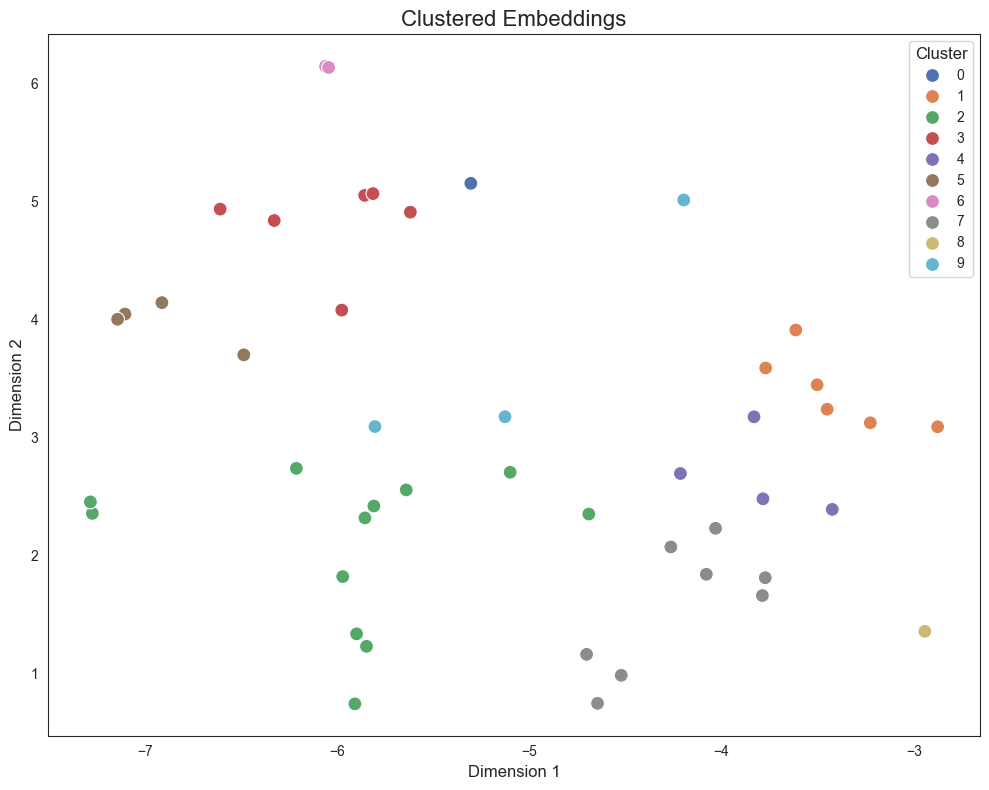

In [39]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 경고 제거
import warnings

warnings.filterwarnings("ignore")

# t-SNE 수행 및 2차원으로 축소
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.array(vectors))

# seaborn 스타일 설정
sns.set_style("white")

# 축소된 데이터 플롯
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=reduced_data_tsne[:, 0],
    y=reduced_data_tsne[:, 1],
    hue=kmeans.labels_,
    palette="deep",
    s=100,
)
plt.xlabel("Dimension 1", fontsize=12)
plt.ylabel("Dimension 2", fontsize=12)
plt.title("Clustered Embeddings", fontsize=16)
plt.legend(title="Cluster", title_fontsize=12)

# 배경색 설정
plt.gcf().patch.set_facecolor("white")

plt.tight_layout()
plt.show()

In [40]:
import numpy as np

# 가장 가까운 점들을 저장할 빈 리스트 생성
closest_indices = []

# 클러스터 수만큼 반복
for i in range(num_clusters):

    # 해당 클러스터 중심으로부터의 거리 목록 구하기
    distances = np.linalg.norm(vectors - kmeans.cluster_centers_[i], axis=1)

    # 가장 가까운 점의 인덱스 찾기 (argmin을 사용하여 최소 거리 찾기)
    closest_index = np.argmin(distances)

    # 해당 인덱스를 가장 가까운 인덱스 리스트에 추가
    closest_indices.append(closest_index)

In [41]:
closest_indices

[33, 12, 24, 35, 2, 26, 30, 9, 4, 8]

In [42]:
# 문서의 요약을 순서대로 진행하기 위하여 오름차순 정렬
selected_indices = sorted(closest_indices)
selected_indices

[2, 4, 8, 9, 12, 24, 26, 30, 33, 35]

In [43]:
from langchain_core.documents import Document

selected_docs = [Document(page_content=split_docs[doc]) for doc in selected_indices]
selected_docs

[Document(metadata={}, page_content='**ChatGPT의 한계를 보완하기 위해 주목받은 RAG**\n\nRAG는 ChatGPT의 한계를 보완하기 위해 주목받기 시작한 기술입니다. RAG란 Retrieval-Augmented Generation의 줄임말로, 검색(Retrieval), 증강(Augmented), 생성(Generation)이라는 의미를 담고 있으며, 거대 언어 모델(LLM; Large Language Model)이 외부의 신뢰할 수 있는 지식 데이터베이스를 참조하여 최적화된 응답을 생성하는 기술입니다.\n\nRAG의 다양한 방법론을 활용하여 지속적으로 업그레이드하면 ChatGPT만 사용했을 때 50점 수준이었던 답변의 품질을 80점, 90점대로 끌어올릴 수 있습니다. 적절한 RAG를 적용하면 앞서 언급된 문제점들을 다음과 같이 개선할 수 있습니다.'),
 Document(metadata={}, page_content='이해를 돕기 위해 예시를 들어 보겠습니다. RAG를 사용하기 전 ChatGPT에게 다음과 같이 질문해 보았습니다.\n\n“서울특별시에 사는 테디 아버지 이름이 뭐야?"\n\nChatGPT는 이러한 개인적인 질문을 받으면 굉장히 황당할 겁니다. 테디가 누구인지, 그의 아버지 이름이 뭔지 어떻게 알겠냐고요. 이런 경우 모른다고 답하거나 답변하는 과정에서 잘못된 정보를 생성(할루시네이션)할 가능성이 높습니다. 하지만 다음과 같은 가족관계증명서를 GPT에게 주면 어떻게 될까요? GPT는 자료를 참고해서 테디 아버지 이름은 \'폴\'이라고 정확한 답변을 제공할 수 있을 것입니다.\n\n**이미지 1: 가족관계증명서(상세) 차트**\n서울특별시에 등록된 가족관계증명서의 상세 내역을 보여줍니다.\n- 등록기준지: 서울특별시\n- 본인: 테디 (출생연월일 및 주민등록번호는 빈칸)\n- 가족사항: 부(아버지) - 폴, 모(어머니) - 설리, 자녀(두 명)는 빈칸으로 표시되어 있습니다.'),
 Document(metadata

In [ ]:
# 이전에 생성한 map_refine_chain을 사용하여 요약 생성
cluster_refined_summary = map_refine_chain.invoke(selected_docs)
print(cluster_refined_summary)

--- 각 문서 개별 요약 (Map) 결과 ---
[1번 문서 요약]: - RAG(Retrieval-Augmented Generation)는 ChatGPT의 한계를 보완하기 위해 주목받는 기술입니다.
- 이 기술은 거대 언어 모델(LLM)이 외부의 신뢰할 수 있는 지식 데이터베이스를 참조하여 최적화된 응답을 생성합니다.
- RAG를 활용하면 ChatGPT 단독 사용 시 50점 수준이던 답변 품질을 80~90점대로 크게 향상시킬 수 있습니다.
[2번 문서 요약]: *   RAG(Retrieval Augmented Generation)는 LLM(대규모 언어 모델)이 외부 정보를 참조하여 질문에 대한 정확한 답변을 제공하도록 돕는 기술이다.
*   외부 정보 없이 개인적인 질문을 받으면 LLM은 답변 불가 또는 잘못된 정보(환각)를 생성할 가능성이 높다.
*   하지만 RAG를 통해 관련 문서(예: 가족관계증명서)를 제공하면, LLM은 해당 정보를 바탕으로 정확한 답변을 도출하여 답변의 신뢰성과 정확성을 크게 향상시킬 수 있다.
[3번 문서 요약]: -   ChatGPT는 문서 내용을 바탕으로 한 질문에도 불구하고, 특정 데이터(유로존 실업률)를 제공하지 못하는 문제가 발생했습니다.
-   이는 KDI 경제전망 PDF 문서의 'II. 세계경제 동향' 섹션에 "3/4분기 유로존의 전체 및 청년실업률은 전분기에 이어 각각 6.5%, 14.0%의 낮은 수준을 기록"이라는 문장이 명확히 존재함에도 불구하고 발생한 현상입니다.
-   해당 정보는 문서 내에서 빨간색 박스로 강조되어 있었으며, 유로존 실업률 관련 차트도 함께 제시되어 있었습니다.
[4번 문서 요약]: - ChatGPT는 문서 기반 질문에 대해 구체적인 질문 시 할루시네이션을 일으킬 수 있습니다.
- OpenAI가 ChatGPT의 RAG 작동 방식을 공개하지 않아 사용자가 직접 제어할 수 없습니다.
- 문서를 FAQ나 마크다운 형식으로 변환하는 방법이 있지만, 모든 문서에 적용하기에는 시간과 노력이 많이 들어 

# map-refined summary
LLM의 성능 향상은 RAG(Retrieval-Augmented Generation)를 통한 '컨텍스트 최적화'와 프롬프트 엔지니어링, 파인 튜닝과 같은 'LLM 최적화' 기법이 결합될 때 '전체 활용'을 이룬다. 특히 RAG는 일반적인 LLM이 프롬프트만을 기반으로 답변을 생성하는 것과 달리, LLM의 한계를 보완하기 위해 외부의 신뢰할 수 있는 지식 데이터베이스에서 관련 문서를 검색하는 '리트리버' 단계를 추가한다. 검색된 문서는 사용자 질문과 함께 '컨텍스트'로 프롬프트에 포함되어 LLM이 최적화된 응답을 생성하도록 돕는다. 이를 통해 LLM은 사전 학습된 내용 외에 최신 정보 및 내부 데이터에 특화된 답변을 제공할 수 있으며, 최신 정보 기반 응답 성능에서 프롬프트 엔지니어링, PEFT, Full Fine-Tuning보다 가장 높은 성능을 보인다. RAG는 LLM 답변의 정확도를 획기적으로 개선하는데, 코사인 유사성을 이용한 기본 검색이 45%의 정확도를 보인 반면, HyDE 검색, 파인 튜닝 임베딩, 청크 분할/임베딩을 적용하면 65%로, 순위 재조정 및 카테고리 분류를 통해 85%까지 향상된다. 특히 프롬프트 엔지니어링 도구 사용 및 쿼리 확장을 적용했을 때 98%로 가장 높은 정확도를 달성한다. 이는 ChatGPT 단독 사용 시 50점 수준이던 답변 품질을 80~90점대로 크게 향상시키는 것과 더불어 최신 정보 및 내부 데이터 학습 한계로 인한 특정 도메인 질문 답변의 제약을 해소한다.

RAG 시스템은 사용자의 질문에 답변하기 전, '전처리 과정'을 거친다. 이 과정에서 다양한 원본 문서에서 텍스트를 추출하고, 추출된 텍스트를 맥락 유지를 위해 일부 겹치는 '청크 오버랩' 방식을 사용하여 더 작은 '청크'로 분할한다. 복잡한 텍스트 정보는 벡터(임베딩)로 변환되며, 이 임베딩 값은 비용 효율성을 위해 벡터 스토어에 저장된다. 이후 리트리버 단계에서는 사용자 질문을 벡터로 변환한 후, 벡터 스토어 내 문서 벡터들과 코사인 유사성이나 MMR 같은 알고리즘을 활용하여 유사도를 계산하고, 가장 관련성 높은 청크를 사용자 질문에 대한 컨텍스트로 선택한다. 리트리버의 성능은 시스템 응답 품질과 직결된다. 예를 들어, OpenAI의 임베딩 벡터는 1536차원으로, 차원이 높을수록 정교한 유사도 비교가 가능하지만 더 많은 리소스를 소모한다. 임베딩은 복잡한 자연어의 의미를 정량화된 숫자 값으로 변환하여 컴퓨터가 텍스트 내용을 더 잘 이해하고 처리할 수 있도록 돕는다. 질문과 관련성 있는 정보만을 선별하여 검색기에 전달하는 과정이 RAG 프로세스의 사전 단계로 중요하게 작용하며, 최종적으로 검색된 정보와 프롬프트가 LLM으로 전달되어 실제 응답을 생성한다. 이 과정은 LLM의 능력을 최대한 활용하여 사용자 질문에 대한 정확하고 자연스러운 답변을 만들며, 앞선 모든 과정의 결과물을 사용자가 이해할 수 있는 형태로 변환하는 최종 관문 역할을 한다.

LLM이 외부 참조 정보 없이 답변할 경우 할루시네이션을 일으킬 가능성이 높지만, RAG는 관련 문서를 제공하여 답변의 신뢰성과 정확도를 크게 향상시킨다. RAG는 유효한 정보만을 기반으로 답변을 도출하거나 주어진 문서에서만 답변의 출처를 찾도록 강제하여 할루시네이션 현상을 효과적으로 줄이며, 프롬프트 엔지니어링, PEFT, Full Fine-Tuning 등 다른 기술보다 할루시네이션 회피 능력이 가장 뛰어나다. 특히, 저장된 데이터베이스에서 답변의 출처를 역으로 검색하고 검증함으로써 응답 정확도를 대폭 향상시킨다. 또한, RAG는 다른 AI 기술들에 비해 답변 생성 과정의 전 단계를 모니터링하고 추적할 수 있어 가장 높은 투명성과 해석 가능성을 제공한다. LangSmith와 같은 도구를 활용하면 'RunnableSequence'의 실행 과정을 시각적으로 추적하고, 각 단계의 소요 시간, 입력 질문, 출력 답변, 검색된 문서 목록 및 출처, 구체적인 텍스트 내용까지 상세히 분석할 수 있어 LLM의 답변 도출 과정을 심층적으로 이해하고 성능 개선에 활용할 수 있다.

RAG 시스템의 성능과 답변의 정교함은 다양한 정보 검색 기술을 활용하고, GPT가 참고할 데이터를 핵심 정보 위주로 정제함으로써 더욱 고도화될 수 있다. 특히, RAG에 파인 튜닝(미세 조정)을 더하면 모델의 잠재력을 최고 수준으로 끌어올려 상세한 답변을 얻고 할루시네이션 현상도 더욱 효과적으로 줄일 수 있다. 또한, 민감한 개인/회사 정보 업로드 시 발생할 수 있는 보안 문제를 방지한다. RAG는 구현 복잡도 측면에서 프롬프트 엔지니어링보다는 높지만, 완전 파인 튜닝이나 PEFT와 같은 다른 언어 모델 성능 향상 기술보다는 낮은 중간 수준으로 실용적이며, 사용자가 데이터베이스와 모델을 커스터마이즈하여 특정 도메인에 최적화된 챗봇을 제작할 수 있다. 다만, ChatGPT의 내장 RAG 시스템은 답변 출처 확인의 어려움과 커스터마이징 제한으로 투명성과 신뢰도 문제가 발생할 수 있으며, 문서 내용과 다른 답변(할루시네이션)을 생성할 수 있는 한계가 있다. 이러한 한계를 극복하고 문서 검색 정확도를 높이기 위해서는 LangChain, LangSmith, LangGraph, LangServe 등 LLM 기반 애플리케이션 개발에 필수적인 LangChain 생태계 도구들을 활용하여 RAG 시스템의 전체 프로세스를 직접 구현하고 세부 알고리즘을 '튜닝'하는 것이 필요하다. 특히, LCEL(LangChain Expression Language) 문법을 활용한 체인 생성 단계는 RAG 파이프라인을 완성하는 마지막 과정으로, 이를 통해 기존 RAG 시스템의 한계를 극복하고, 원하는 형태의 답변을 얻기 위해 각 과정을 투명하게 개선할 수 있게 한다. LangChain은 GPT 기반 Q&A 시스템 구축 시 문서 텍스트를 쉽게 처리하고, 복잡한 파이썬 코드 대신 한두 줄로 기능을 구현할 수 있게 하며, 데이터베이스, 임베더, 문서 종류 등을 유연하게 선택할 수 있어 그 적용 분야와 산업 규모가 빠르게 성장하고 있다. 궁극적으로 이러한 체계적인 방법론 정립을 통해 다양한 비즈니스 환경에서 활용 가능한 고성능 RAG 시스템을 구축하는 것이 목표다.

In [46]:
print(refined_summary)

RAG(Retrieval-Augmented Generation)는 거대 언어 모델(LLM)이 외부 정보 없이 질문에 답변할 때 발생할 수 있는 잘못된 정보(환각) 생성이나 답변 불가와 같은 한계를 보완하기 위해 주목받는 기술입니다. 특히 ChatGPT와 같은 LLM은 문서 기반의 구체적인 질문에 대해 할루시네이션을 일으키거나, OpenAI가 RAG 작동 방식을 공개하지 않아 사용자가 직접 제어할 수 없는 한계가 있습니다. 실제로 ChatGPT는 KDI 경제전망 PDF 문서에 "3/4분기 유로존의 전체 및 청년실업률은 전분기에 이어 각각 6.5%, 14.0%의 낮은 수준을 기록"이라는 문장이 명확히 존재하고 빨간색 박스로 강조되어 있었음에도 불구하고, 해당 유로존 실업률 정보를 질문에 제공하지 못하는 한계를 보이기도 했습니다. 이러한 한계는 물론, 문서를 FAQ나 마크다운 형식으로 변환하는 방식은 모든 문서에 적용하기 비현실적이라는 점을 고려할 때, LangChain을 활용하여 RAG 시스템을 직접 구축하는 것이 효과적인 대안으로 제안됩니다. **이러한 RAG 시스템은 답변 생성 과정의 모든 단계를 사용자가 직접 설계하고 모니터링할 수 있어, 답변의 투명성과 해석 가능성 측면에서 압도적인 강점을 가집니다.** 이 기술은 LLM이 외부의 신뢰할 수 있는 지식 데이터베이스나 관련 문서를 참조하여 질문에 대한 정확하고 신뢰할 수 있는 응답을 생성하도록 돕습니다. **구체적으로, RAG 질의-응답 흐름은 사용자 질문이 입력되면, 이 질문 또한 벡터 값으로 변환된 후, 리트리버가 미리 업로드되어 벡터 스토어에 저장된 텍스트 청크들의 벡터 값과 질문 벡터 간의 유사도를 계산하여 가장 적합한 관련 내용을 검색합니다. 검색된 정보는 '참고 정보(context)'로 프롬프트에 삽입되어 LLM이 이를 바탕으로 답변을 생성합니다. 이 과정에는 데이터 소스를 벡터 스토어로 만드는 사전 단계가 포함되는데, 이는 '문서 로드', '텍스트 분할', '임베딩', '벡터 스토어 저장'의 네 